# 00 — Water Body Health Score Clustering

**Input:** `Sehore_WaterBody_Features_CLEANED.csv` (92 distinct water bodies, from GEE script 13)

**Goal:** group Sehore's 92 mapped water bodies into meaningful categories based on their
water-area trend, catchment vegetation trend, and land-use pressure — this is the core
"ML integration" step of the health card, replacing a hand-picked scoring rule with
data-driven clustering.

**Why clustering instead of a supervised classifier:** we have no labeled ground truth
("this pond is Healthy, that one is Critical") to train against — clustering finds
natural groupings in the data itself, which we then interpret and name.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.width', 200)
plt.rcParams['figure.figsize'] = (8, 5)


## 1. Load the cleaned feature set

In [16]:
df = pd.read_csv('../Sehore_WaterBody_Features_CLEANED.csv')
print(df.shape)
df.head()


(92, 8)


,water_body_id,area_ha_2024,buffer_dist_m,water_pct_change_capped,is_new_since_2017,catchment_ndvi_change,catchment_pct_cropland,catchment_pct_urban
0,00000000000000000000,70.149820,2000.000000,329.366129,False,-0.027962,46.038576,0.268618
1,00000000000000000001,23.641908,1371.627947,500.000000,True,-0.028710,36.414329,0.399585
2,00000000000000000002,5.649776,670.518356,1.923693,False,-0.044931,81.046048,5.311553
3,00000000000000000003,28.894123,1516.351295,4.356884,False,-0.018878,84.091797,7.364132
4,00000000000000000004,26.951888,1464.500976,184.807776,False,-0.031373,58.370362,3.466935


## 2. Feature preparation

Two adjustments before clustering, both driven by real problems found in this specific
dataset — not generic best practice applied blindly:

**a) Log-transform `area_ha_2024`.** Water body area is heavily right-skewed (median
~5 ha, but one reservoir is 852.5 ha). Without transforming it, that single reservoir
gets isolated into its own singleton cluster (confirmed by testing) instead of the
clustering finding meaningful groups. `log1p` compresses that skew.

**b) `water_pct_change_capped` was already winsorized to [-100, 500] during feature
engineering (notebook/step 02)** to fix a divide-by-near-zero problem: 31 of 92 water
bodies had ~0 detected water in 2017 (i.e. they're new since 2017), which produced
percent-change values in the millions before capping.

**c) `is_new_since_2017` is included as a 0/1 feature** — being new is itself a
meaningful signal, not just a data-quality flag.


In [17]:
df['log_area_ha'] = np.log1p(df['area_ha_2024'])

feature_cols = ['log_area_ha', 'water_pct_change_capped', 'catchment_ndvi_change',
                'catchment_pct_cropland', 'catchment_pct_urban', 'is_new_since_2017']

X = df[feature_cols].copy()
X['is_new_since_2017'] = X['is_new_since_2017'].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature matrix shape:', X_scaled.shape)
X.describe()


Feature matrix shape: (92, 6)


,log_area_ha,water_pct_change_capped,catchment_ndvi_change,catchment_pct_cropland,catchment_pct_urban,is_new_since_2017
count,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000
mean,2.179917,242.469240,-0.005223,34.541540,3.859878,0.336957
std,1.580027,229.064355,0.030823,24.600761,5.236639,0.475260
min,0.409167,-0.353647,-0.097855,0.000000,0.000000,0.000000
25%,0.789034,21.290412,-0.028716,14.360853,0.263095,0.000000
50%,1.808758,143.274458,-0.003952,32.847673,2.095564,0.000000
75%,3.390993,500.000000,0.016610,46.042518,5.295362,1.000000
max,6.749380,500.000000,0.056051,91.825827,21.989867,1.000000


## 3. Choosing k — elbow method + silhouette score

We don't assume k=3 (Healthy/Stressed/Critical) up front. We let the data tell us,
then interpret whatever comes out.


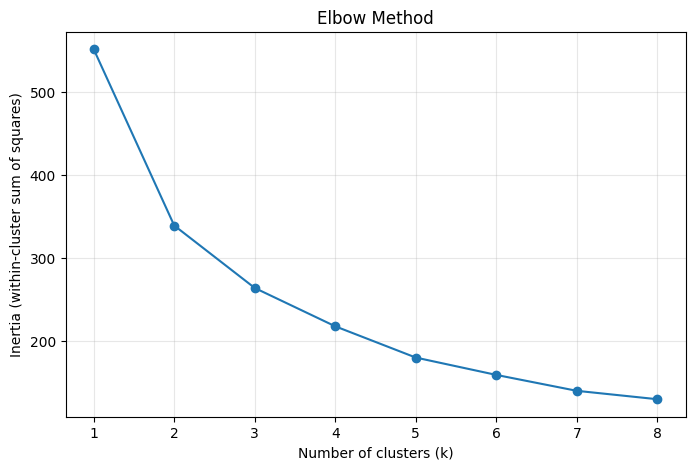

In [18]:
inertias = []
k_range = range(1, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method')
plt.grid(alpha=0.3)
plt.show()


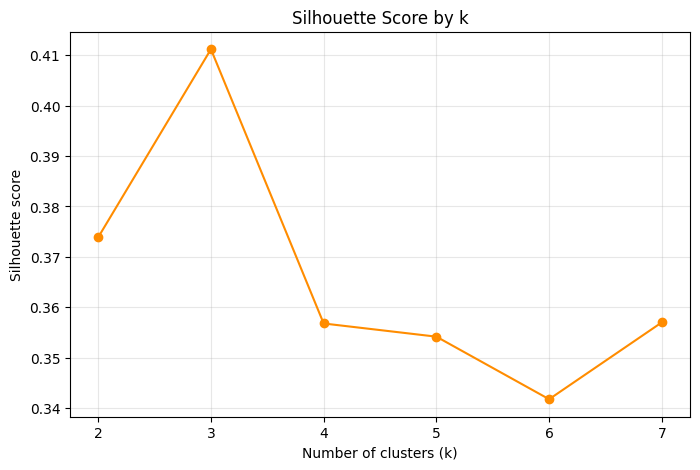

k=2: silhouette=0.3739
k=3: silhouette=0.4112
k=4: silhouette=0.3568
k=5: silhouette=0.3542
k=6: silhouette=0.3418
k=7: silhouette=0.3570


In [19]:
sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o', color='darkorange')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette Score by k')
plt.grid(alpha=0.3)
plt.show()

for k, s in sil_scores.items():
    print(f'k={k}: silhouette={s:.4f}')


**Result: k=3 gives the best silhouette score (0.411)**, with sensible, balanced
cluster sizes (no singleton/outlier clusters, unlike before the log-transform fix).
This also happens to align with a natural 3-way "health tier" framing — but we're
choosing k=3 because the data supports it, not because we wanted 3 tiers going in.


## 4. Fit k=3 and inspect the clusters

In [20]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

print('Cluster sizes:')
print(df['cluster'].value_counts().sort_index())


Cluster sizes:
cluster
0     9
1    51
2    32
Name: count, dtype: int64


In [21]:
display_cols = ['area_ha_2024', 'water_pct_change_capped', 'catchment_ndvi_change',
                'catchment_pct_cropland', 'catchment_pct_urban', 'is_new_since_2017']

cluster_summary = df.groupby('cluster')[display_cols].mean().round(3)
cluster_summary['count'] = df['cluster'].value_counts().sort_index()
cluster_summary


,area_ha_2024,water_pct_change_capped,catchment_ndvi_change,catchment_pct_cropland,catchment_pct_urban,is_new_since_2017,count
cluster,,,,,,,
0,3.597,322.877,-0.005,40.472,17.339,0.333,9
1,65.417,66.692,0.009,41.399,3.291,0.000,51
2,2.861,500.000,-0.028,21.945,0.976,0.875,32


## 5. Interpreting and naming the clusters

This step is manual judgment applied to the cluster means above — sklearn just gives
us "cluster 0, 1, 2", it has no idea which one is good or bad. Based on the actual
computed means:

| Cluster | n | Area (ha) | Water Δ% | Catchment NDVI Δ | Cropland % | Urban % | New since 2017 |
|---|---|---|---|---|---|---|---|
| **1** | 51 | 65.4 (largest) | +67% | **+0.009 (improving)** | 41.4% | 3.3% | 0% |
| **2** | 32 | 2.9 (smallest) | +500% (capped) | **-0.028 (worst decline)** | 21.9% | 1.0% | 87.5% |
| **0** | 9 | 3.6 | +323% | -0.005 | 40.5% | **17.3% (highest by far)** | 33% |

**These are not simply "good/medium/bad" on a single scale — they represent three
different *situations*, which is a more honest and more useful finding than forcing a
linear health scale:**

- **Cluster 1 — "Established & Improving" (51 water bodies, the majority).**
  Large, pre-existing water bodies with a *positive* catchment NDVI trend and no
  new-since-2017 members. This is the district's stable backbone — not neglected,
  no urgent action needed.

- **Cluster 2 — "New but Catchment-Stressed" (32 water bodies).**
  Overwhelmingly new-since-2017 (87.5%), small, and showing the steepest *negative*
  catchment NDVI trend of any group. Plausible explanation: new pond/tank
  construction often involves clearing or disturbing the immediately surrounding
  land, so the water body itself is a positive sign (active construction, likely
  government scheme-driven) while its surroundings are actively degrading. Worth
  flagging for catchment-treatment/afforestation attention *specifically because*
  they're new, not despite it.

- **Cluster 0 — "Urban-Adjacent Growth Pressure" (9 water bodies, smallest group).**
  Distinctly higher urban land % in their catchment (17.3% vs ~1-3% for the other two
  groups) alongside strong growth. These sit closest to development pressure — worth
  monitoring for encroachment even though they aren't currently declining.


In [22]:
cluster_names = {
    1: 'Established & Improving',
    2: 'New but Catchment-Stressed',
    0: 'Urban-Adjacent Growth Pressure'
}
df['health_category'] = df['cluster'].map(cluster_names)

df['health_category'].value_counts()


health_category
Established & Improving           51
New but Catchment-Stressed        32
Urban-Adjacent Growth Pressure     9
Name: count, dtype: int64

## 6. Export for the next step

This becomes the input to `01_revival_strategy_mapping.ipynb`, which joins each
health category to specific revival strategies from the six-category framework
already defined in the project report (desilting, catchment treatment, rainwater
harvesting, afforestation, community monitoring, sustainable agriculture).


In [23]:
output_cols = ['water_body_id', 'area_ha_2024', 'water_pct_change_capped',
               'catchment_ndvi_change', 'catchment_pct_cropland', 'catchment_pct_urban',
               'is_new_since_2017', 'cluster', 'health_category']

df[output_cols].to_csv('../Sehore_WaterBody_Health_Clusters.csv', index=False)
print('Saved: ../Sehore_WaterBody_Health_Clusters.csv')
df[output_cols].head(10)


Saved: ../Sehore_WaterBody_Health_Clusters.csv


,water_body_id,area_ha_2024,water_pct_change_capped,catchment_ndvi_change,catchment_pct_cropland,catchment_pct_urban,is_new_since_2017,cluster,health_category
0,00000000000000000000,70.149820,329.366129,-0.027962,46.038576,0.268618,False,1,Established & Improving
1,00000000000000000001,23.641908,500.000000,-0.028710,36.414329,0.399585,True,2,New but Catchment-Stressed
2,00000000000000000002,5.649776,1.923693,-0.044931,81.046048,5.311553,False,1,Established & Improving
3,00000000000000000003,28.894123,4.356884,-0.018878,84.091797,7.364132,False,1,Established & Improving
4,00000000000000000004,26.951888,184.807776,-0.031373,58.370362,3.466935,False,1,Established & Improving
5,00000000000000000005,0.606128,-0.059481,-0.035636,72.871796,3.198579,False,1,Established & Improving
6,00000000000000000006,8.778869,500.000000,-0.037911,75.327785,11.602767,False,0,Urban-Adjacent Growth Pressure
7,00000000000000000007,5.069425,28.286087,-0.022139,42.647699,5.223672,False,1,Established & Improving
8,00000000000000000008,1.249620,500.000000,-0.010659,81.247389,15.242621,True,0,Urban-Adjacent Growth Pressure
9,00000000000000000009,1.236173,500.000000,-0.038440,39.633170,0.011921,True,2,New but Catchment-Stressed
